Alignment of full slices

In [1]:
import torch
import pandas as pd
from scipy.spatial import distance
import numpy as np
from raftup import (
    _downsample,
    _fsgw_utils,
    _fsgw_utils_test_sparse,
    _metrics_two_gpr,
    _load_data,
    _plot,
    _recoverfull_new_new_knn
)

/opt/anaconda3/envs/raftup_verify2/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/raftup_verify2/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/anaconda3/envs/raftup_verify2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
#  load anndata and downsampled data

section_ids_list = [['151508', '151509']]
pair = "151508_151509"

for section_ids in section_ids_list:
    dataset = section_ids[0] + '_' + section_ids[1]

    sliceA = _load_data.load_DLPFC(section_id=section_ids[0])
    sliceB = _load_data.load_DLPFC(section_id=section_ids[1])

random_state = 23
np.random.seed(random_state)
tar_distance = 1020

downsampled_sliceA,indices_dsa = _downsample.downsample_slice(sliceA, tar_distance)


downsampled_sliceB,indices_dsb = _downsample.downsample_slice(sliceB, tar_distance)


np.save(f"./results/align_data/{pair}_downsample_indices_dsa.npy", indices_dsa)
np.save(f"./results/align_data/{pair}_downsample_indices_dsb.npy", indices_dsb)

/private/tmp/raftup_verify_repo2/src/raftup/_load_data.py:12: FutureWarning: Use `squidpy.read.visium` instead.
  ad = sc.read_visium(path=os.path.join(root_dir, section_id), count_file=section_id+'_filtered_feature_bc_matrix.h5')
/opt/anaconda3/envs/raftup_verify2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/anaconda3/envs/raftup_verify2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/private/tmp/raftup_verify_repo2/src/raftup/_load_data.py:12: FutureWarning: Use `squidpy.read.visium` instead.
  ad = sc.read_visium(path=os.path.join(root_dir, section_id), count_file=section_id+'_filtered_feature_bc_matrix.h5')
/opt/anaconda3/envs/raftup_verify2/lib/python3.10/site-packages/anndata/_core/annd

In [3]:
# load gene cost

PT_PATH = f"./results/gene_cost_matrix/{pair}_somde_cost_matrix.pt"

C = torch.load(PT_PATH, map_location="cpu")  
M = C.numpy() 

D_A_test = distance.cdist(downsampled_sliceA.obsm['spatial'], downsampled_sliceA.obsm['spatial'])
D_B_test = distance.cdist(downsampled_sliceB.obsm['spatial'], downsampled_sliceB.obsm['spatial'])

testA = D_A_test[D_A_test>0]
testB = D_B_test[D_B_test>0]
print(np.min(testA), np.min(testB))

137.00364958642524 279.0788419067271


Check the performance of downsampled alignment. In general, better downsampled alignment induces better full alignment.

GW cutoff: 279
Loading downsampled matching from: results/align_data/ds_matching_151508_151509_206_0.2_turbo.npy
0.8705882352941177 0.12941176470588237 0.0 0.0 0.0 0.0 0.0
transported P_1 mass: 0.4473684210526131
binarized transported ratio: 0.46195652173913043
full_LAA: 0.8705882352941177
Number of columns with >=2 nonzeros: 0
(184, 190)


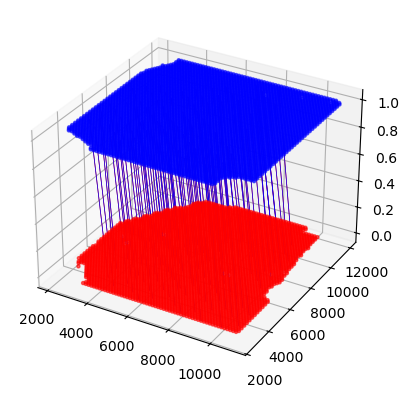

In [4]:
# load downsampled alignment

from pathlib import Path
import numpy as np

cutoff_GW_standard = int(np.max([np.min(testA), np.min(testB)]))
print("GW cutoff:", cutoff_GW_standard)


SAVE_DIR = Path("./results/align_data")

load_path = SAVE_DIR / f"ds_matching_{pair}_{206}_{0.2}_turbo.npy"

print("Loading downsampled matching from:", load_path)

P_1 = np.load(load_path)

P_hard = np.zeros_like(P_1)
row_max_idx = P_1.argmax(axis=1)  
P_hard[np.arange(P_1.shape[0]), row_max_idx] = P_1[np.arange(P_1.shape[0]), row_max_idx]

test_label_sub = np.concatenate((np.array(downsampled_sliceA.obs['original_clusters']),np.array(downsampled_sliceB.obs['original_clusters'])),axis=0)
XA_sub = downsampled_sliceA.obsm['spatial']
XB_sub = downsampled_sliceB.obsm['spatial']

full_dela_raftup_LAA = _metrics_two_gpr.cal_layer_based_alignment_result_full_skip_all_zero(P_hard, test_label_sub)

nonzero_rows = np.count_nonzero(np.any(P_hard != 0, axis=1))
n_rows = P_hard.shape[0]

print("transported P_1 mass:", P_1.sum())
print("binarized transported ratio:", nonzero_rows / n_rows)
print("full_LAA:", full_dela_raftup_LAA[0])

col_nnz = np.count_nonzero(P_hard, axis=0)  
conflict_cols = np.where(col_nnz >= 2)[0]
num_conflict_cols = len(conflict_cols)

print("Number of columns with >=2 nonzeros:", num_conflict_cols)

print(P_hard.shape)

_plot.plot_3d(sliceA.obsm['spatial'], sliceB.obsm['spatial'], P_hard, indices_dsa, indices_dsb, linewidth=0.5)

In general, the gene cutoff \rho_{f_2} in full alignment is larger than the gene cutoff \rho_{f_1} in downsampled alignment to enlarge more spots aligned near the anchor spots (downsampled/aligned spots). 
A preferable ratio of \rho_{f_2} over \rho_{f_1} is 2.

The spatial cutoff \rho_t is the same as the spatial cutoff \rho_s in downsampled alignment. 
In general, a preferable ratio of \rho_s over \rho_s is less than or equal to 1.

k_1 and k_2 are two parameters for generating the spatial cost of full slices given aligned anchor spots. For spot \alpha in sliceA and spot \beta in sliceB, the spatical cost between \alpha and \beta is fully determined by the k_1 aligned anchor spots of subsliceA and the k_2 aligned anchor spots of subsliceB. 
The default k_1 = k_2 = 10.

In [5]:
# knn recover full

thresh_CCC_list = {0.4}

thresh_CGW_list = {206}


test_label_full = np.concatenate((np.array(sliceA.obs['original_clusters']),np.array(sliceB.obs['original_clusters'])),axis=0)
XA_full = sliceA.obsm['spatial']
XB_full = sliceB.obsm['spatial']

for thresh_CCC in thresh_CCC_list:
    for thresh_CGW in thresh_CGW_list:
        print(f"Running alignment for section pair")
        P_full_knn = _recoverfull_new_new_knn.recover_full_mapping_knn(
            M = M,
            X1 = sliceA.obsm['spatial'],
            X2 = sliceB.obsm['spatial'],
            P  = P_hard,
            idx1 = indices_dsa,
            idx2 = indices_dsb,
            k1 = 10,         
            k2 = 10,         
            thresh_CGW=thresh_CGW, 
            thresh_CCC=thresh_CCC, 
            eps=0.01
        )
        P_full_dense_knn = P_full_knn.toarray()

        full_dela_raftup_LAA = _metrics_two_gpr.cal_layer_based_alignment_result_full_skip_all_zero(P_full_dense_knn, test_label_full)
        full_dela_raftup_GPR_300= _metrics_two_gpr.GPR_original(P_full_dense_knn , XA_full, XB_full, dis_cut=300, P_cut=1e-19)
        full_dela_raftup_GPR_600= _metrics_two_gpr.GPR_original(P_full_dense_knn , XA_full, XB_full, dis_cut=600, P_cut=1e-19)
        full_dela_raftup_GPR_900= _metrics_two_gpr.GPR_original(P_full_dense_knn , XA_full, XB_full, dis_cut=900, P_cut=1e-19)

        print("thresh CCC is:", thresh_CCC )
        print("thresh CGW is:", thresh_CGW )
        print("transported mass:", P_full_dense_knn.sum())
        print("full_dela_raftup_LAA:", full_dela_raftup_LAA[0])

        print("full_dela_raftup_GPR_300:", full_dela_raftup_GPR_300)
        print("full_dela_raftup_GPR_600:", full_dela_raftup_GPR_600)
        print("full_dela_raftup_GPR_900:", full_dela_raftup_GPR_900)
        np.save(f'./results/align_data/full_matching_{pair}_{thresh_CGW}_{thresh_CCC}.npy',P_full_dense_knn)

Running alignment for section pair


recover_full_mapping_knn:  62%|██████▎   | 5/8 [02:38<01:47, 35.85s/it]

Number of blocked positions in recover_full sOT (kNN): 20961693
Number of possible aligned positions (kNN): 14535


Number of iterations in unot: 15011, final error: 9.89e-09
0.8671351006068349 0.1306291919514532 0.0 0.0 0.0 0.0 0.002235707441711913
thresh CCC is: 0.4
thresh CGW is: 206
transported mass: 0.6497482769542751
full_dela_raftup_LAA: 0.8671351006068349
full_dela_raftup_GPR_300: 0.8624001047963583
full_dela_raftup_GPR_600: 0.9065542319241768
full_dela_raftup_GPR_900: 0.9359730165214817
